In [1]:
# General
import os
import glob

# Display
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns

# Data treatment
import xarray as xr
import numpy as np
# from scipy.interpolate import griddata
from scipy.optimize import curve_fit
import pandas as pd 
from tqdm.notebook import tqdm
import ephem

# Default parameters
fontsize = 16
mpl.rcParams.update({'font.size': fontsize})
mpl.rcParams['figure.figsize'] = (15, 10)
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.facecolor'] = 'white'

In [2]:
PRMS = {
    'ibt_vars2keep':    ['usa_lon', 'usa_lat', 'usa_pres', 'usa_wind', 'usa_r34', 'usa_r50', 'usa_r64', 'usa_rmw', 'storm_speed', 'storm_dir', 'name', 'sid'],
    'ibt_info2keep':    ['sid', 'basin', 'name', 'usa_atcf_id', 'usa_agency', 'iso_time', 'usa_status'],
}

PTHS = {
    'sar_pth': '/home/arthur/data/tropical_cyclones/SAR/parametric_dataset/dsg.nc',
    'sar_dir': '/home/arthur/data/tropical_cyclones/SAR/S1_RS2_RCM/sar_files/',
    'sav_dir': '/home/arthur/results/TCsLifeMonitFromObs/PRJCT_UC_DIAGNOSTIC/01_PLOT_DIAGNOSTIC/',
    'ibt_pth': '/home/arthur/data/tropical_cyclones/ibtracs/24032025/IBTrACS.ALL.v04r01.nc',
}

### Open data
# SAR
dsg  = xr.open_dataset(PTHS['sar_pth'])

# IBTrACS
ds_ibt_all = xr.open_dataset(PTHS['ibt_pth'])
# Select variables
ds_ibt                        = ds_ibt_all[PRMS['ibt_vars2keep']]
ds_ibt[PRMS['ibt_info2keep']] = ds_ibt_all[PRMS['ibt_info2keep']].astype(str, copy=False) # Convert byte arrays to strings
# Select dates
# start_date                    = np.datetime64('2009-01-01')
start_date                    = np.datetime64(dsg.time[0].data)
fsi                           = np.nanargmin(np.abs(ds_ibt['time'][:, 0] - start_date)) # First storm index
ds_ibt                        = ds_ibt.isel(storm=slice(fsi, None))
# Convert to m/s and m units
for speed in ['usa_wind', 'storm_speed']:
    ds_ibt[speed]  *= 0.5144
for radius in ['usa_r34', 'usa_r50', 'usa_r64', 'usa_rmw']:
    ds_ibt[radius] *= 1852
# Add mean radii
# Non-zero average!!
ds_ibt['mean_r34'] = xr.where(ds_ibt.usa_r34 != 0, ds_ibt.usa_r34, np.nan).mean(dim='quadrant', skipna=True)
ds_ibt['mean_r50'] = xr.where(ds_ibt.usa_r50 != 0, ds_ibt.usa_r50, np.nan).mean(dim='quadrant', skipna=True)
ds_ibt['mean_r64'] = xr.where(ds_ibt.usa_r64 != 0, ds_ibt.usa_r64, np.nan).mean(dim='quadrant', skipna=True)
# Intensification and growing rates in IBTrACS
ds_ibt['vmx_smth']       = ds_ibt.usa_wind.rolling(date_time=4, center=True, min_periods=2).mean()
ds_ibt['r34_smth']       = ds_ibt.mean_r34.rolling(date_time=4, center=True, min_periods=2).mean()
ds_ibt['vmx_dot_smth']   = ds_ibt.vmx_smth.differentiate(coord='date_time') / 3 # m/s/hr
ds_ibt['r34_dot_smth']   = ds_ibt.r34_smth.differentiate(coord='date_time') / 3 # km/hr
# ==> Add LMI values
new                      = ds_ibt.fillna(-9999)
idx_lmi                  = new.vmx_smth.argmax(dim='date_time')
# LMI
ds_ibt['lmi']            = ds_ibt.usa_wind[:, idx_lmi]
ds_ibt['t_lmi']          = ds_ibt.time[:, idx_lmi]
# time since LMI
dt                       = (ds_ibt.time - ds_ibt.t_lmi)
dt_scds                  = dt.dt.days * 24 * 3600 + dt.dt.seconds # Nb of days + Nb of seconds (>= 0 and less than 1 day) for each element
ds_ibt['t_since_lmi']    = dt_scds # in seconds

In [3]:
def correct_vmx_ibt(vmx_ibt):
    return 0.6967 * vmx_ibt + 6.1992
ds_ibt['vmx_reg'] = correct_vmx_ibt(ds_ibt['usa_wind'])
ds_ibt['basin']   = ds_ibt.usa_atcf_id.str[:2].copy(deep=True)
ds_ibt            = ds_ibt.dropna(dim='storm', how='all', subset=['vmx_reg'])

In [4]:
### GROUP BY BASIN
# SAR
dsg['basin_idx'] = dsg.vmx.copy(deep=True) * np.nan
# basin_keys       = np.unique(dsg.basin)
basin_keys       = np.array(['al', 'cp', 'ep', 'wp', 'io', 'sh']) # Same order like Chavas et al 2016
for t in tqdm(range(len(dsg.time))):
    dsg['basin_idx'][t] = np.where(basin_keys == dsg.isel(time=t).basin.item())[0][0] + 1
basin_keys_combined = np.concatenate((['all'], basin_keys))
# IBTrACS
ds_ibt['basin_idx'] = ds_ibt.lmi.copy(deep=True) * np.nan
for s in tqdm(range(len(ds_ibt.storm))):
    # Returns the basin where storm spent most of its lifetime 
    bsns, ctss         = np.unique(ds_ibt.isel(storm=s).basin.str.lower(), return_counts=True)
    bsn                = [item for item in bsns if item != '']
    cts                = [count for item, count in zip(bsns, ctss) if item != '']
    bsn_with_max_cts   = max(zip(cts, bsn)) # Le tri par défaut de max() se fait sur le premier élément du tuple (le compte)
    bsn_mostOfLifeTime = bsn_with_max_cts[1]   # Le résultat est un tuple (compte, bsn), nous voulons le deuxième élément
    ds_ibt['basin_idx'][s] = np.where(basin_keys == bsn_mostOfLifeTime)[0][0] + 1
basin_keys_combined = np.concatenate((['all'], basin_keys))

  0%|          | 0/2121 [00:00<?, ?it/s]

  0%|          | 0/1160 [00:00<?, ?it/s]

In [9]:
### FILTERS
# SAR
cond = (
    (dsg.center_quality_flag < 2) & 
    (dsg.percent_outside < 50) & 
    (dsg.percent_rmx_inside == 1) &
    (abs(dsg.lat) < 30) & 
    (dsg.rmx < 100000) & 
    (dsg.vmx > 20) &
    (dsg.t_since_lmi_ibt / 3600 >= -6) & 
    (dsg.t_since_lmi_ibt / 3600 <= 6)
)
d    = dsg.where(cond, drop=True)
print(len(d.time))

# IBTrACS
cond = (
    (abs(ds_ibt.usa_lat) < 30) & 
    (ds_ibt.usa_rmw < 100000) & 
    (ds_ibt.vmx_reg > 20)
)
dsi         = ds_ibt.where(cond, drop=True)
dsi_stacked = dsi[['t_since_lmi', 'vmx_reg', 'basin_idx', 'basin']].stack(idx=('storm', 'date_time'))
dsi_stacked = dsi_stacked.dropna(dim='idx', subset=['t_since_lmi', 'vmx_reg', 'basin_idx'])
print(len(dsi_stacked.time))

96
27487


In [6]:
# 1) vmx, rmx, fcor, R34/R50/R64 + comparison with best-track data
# 2) B, rossby, Uc, R+, R0, eventually V+ and V0.
# By basin and by t(LMI)

### 1) By basin

/tmp/ipykernel_18343/274574083.py:237: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(xlabels)
/tmp/ipykernel_18343/274574083.py:306: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(xlabels)


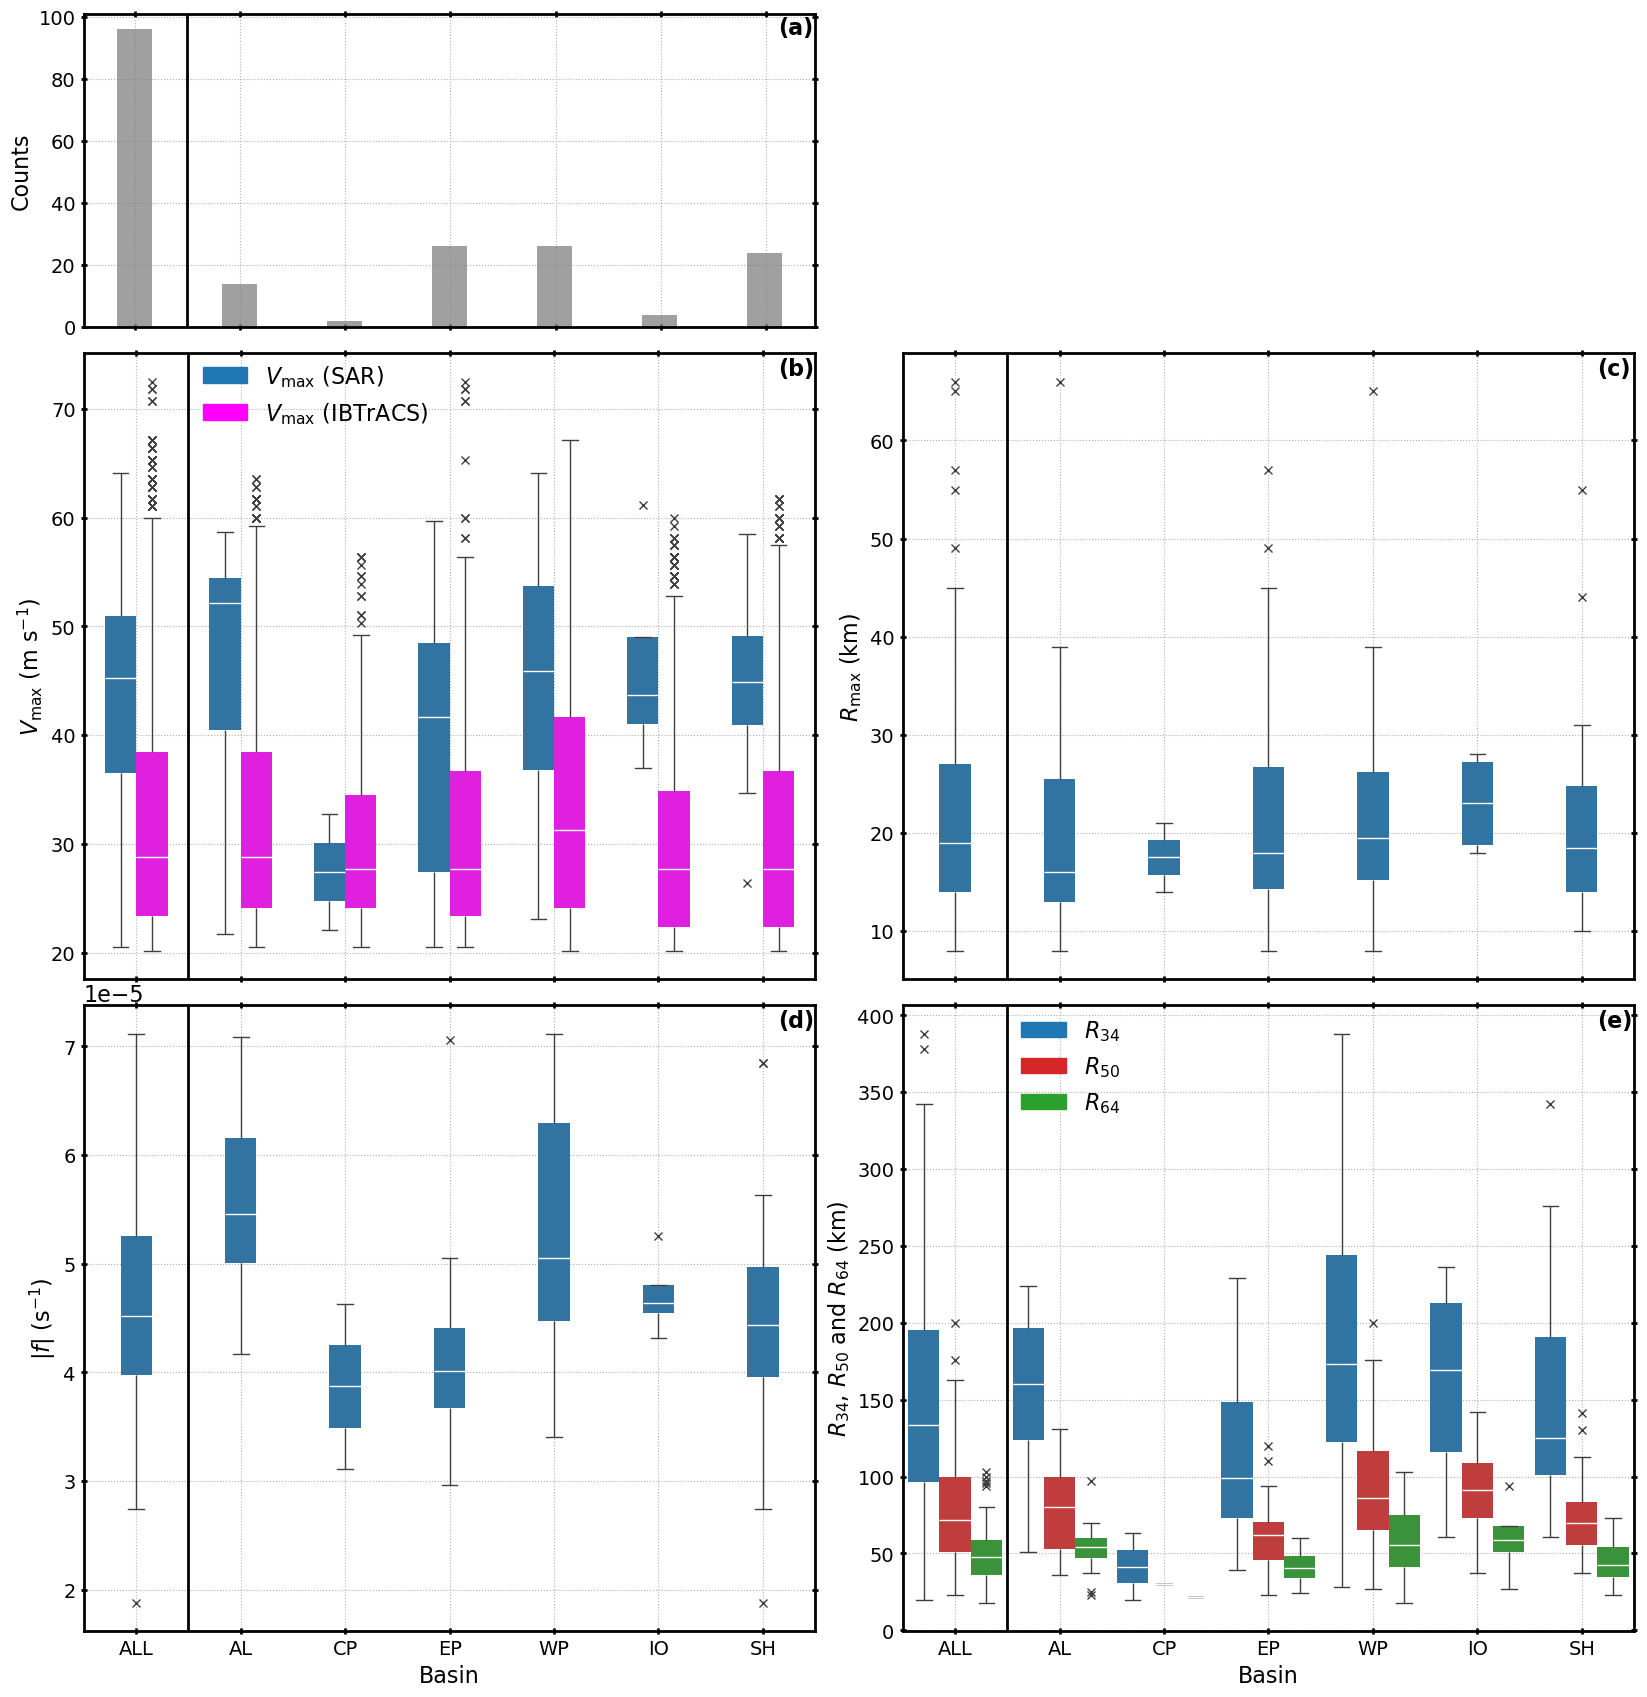

In [12]:
# Hyperparameters
width      = 0.3
bins       = np.arange(0 - width * 1.108 / 2, 6 + width * 1.108 / 2, width * 1.108)
color_glob = 'tab:blue'
color_r50  = 'tab:red'
color_r64  = 'tab:green'

# Fig.
fig        = plt.figure(figsize=(20, 21))
gs         = GridSpec(3, 2, hspace=0.05, wspace=0.12, height_ratios=[1, 2, 2])

##############
### COUNTS ###
##############
ax = fig.add_subplot(gs[0, 0])
ax.text(0.95, 0.935, '(a)', transform=ax.transAxes, weight='bold')

# Data pre.
df                     = d[['basin_idx', 'vmx']].to_dataframe()
df_plot                = df.melt(id_vars='basin_idx', value_vars=['vmx'])
df_global              = df_plot.copy()
df_global['basin_idx'] = 0
df_combined            = pd.concat([df_plot, df_global])

# Boxplot
g = sns.histplot(
    data=df_combined,
    x='basin_idx',
    bins=bins,
    color='grey',
    edgecolor=None,
)

# Separation for All vs. basins
ax.axvline(0.5, c='k', linewidth=2)

# Labels
# xlabels = [basin_keys_combined[round(float(l.get_text()))].upper() for l in g.get_xticklabels()]
# g.set_xticklabels(xlabels)
# g.set_xlabel('Basin')
ax.set_xticklabels([])
ax.set_xlabel('')
g.set_ylabel(r'Counts')
# ax.legend(frameon=False, loc='upper center')
# ax.legend_.remove()
# Put the y ticks label ont the right 
# The same can be done to put the xlabel at the top
ax.yaxis.set_label_position("left") 
plt.xticks(fontsize=fontsize - 2) #the x-ticks 
plt.yticks(fontsize=fontsize - 2) #the y-ticks 

# Grids
# Frame for the plot (do this after the right label position otherwise missing ticks)
ax.spines['left'].set_linewidth(2) #set the width of axis lines -> version without loop
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)       
ax.tick_params(direction='inout', width=2, length=5, bottom=1, top=1, left=1, right=1) #set the tick parameters
ax.grid(ls=':')
ax.set_axisbelow(True) # Set the grid in background

############
### VMAX ###
############
ax = fig.add_subplot(gs[1, 0])
ax.text(0.95, 0.965, '(b)', transform=ax.transAxes, weight='bold')

# Data pre.
df                     = d[['basin_idx', 'vmx']].to_dataframe()
df_plot                = df.melt(id_vars='basin_idx', value_vars=['vmx'])
df_global              = df_plot.copy()
df_global['basin_idx'] = 0
df_combined            = pd.concat([df_plot, df_global])
# Colors
palette                = {'vmx': color_glob}

### Version with IBTrACS
# Reshape the 'vmx_reg' data from dsi into a pandas DataFrame
df_vmx_reg = dsi_stacked[['basin_idx', 'vmx_reg']].drop_vars(names=['time', 'lon', 'lat', 'idx', 'storm', 'date_time']).to_dataframe().reset_index()
df_vmx_reg = df_vmx_reg.melt(id_vars='basin_idx', value_vars=['vmx_reg'])
df_vmx_reg = df_vmx_reg.rename(columns={'vmx_reg': 'value'})
# Add global
df_vmx_reg_global              = df_vmx_reg.copy()
df_vmx_reg_global['basin_idx'] = 0
df_vmx_reg                     = pd.concat([df_vmx_reg, df_vmx_reg_global])
# Combine the new data with the existing data
df_combined = pd.concat([df_combined, df_vmx_reg], ignore_index=True)
# New color palette to include 'vmx' and 'vmx_reg'
palette = {
    'vmx':      color_glob, # Use your specific color for vmx (e.g., color_glob)
    'vmx_reg': 'magenta'    # Choose a new color for the new variable
}
########################

# Boxplot
g = sns.boxplot(
    x='basin_idx', 
    y='value', 
    hue='variable', 
    data=df_combined, 
    boxprops={'edgecolor':'none'},
    palette=palette,
    medianprops={'color': 'white'},
    flierprops=dict(marker='x', color='grey'),
    # width=width,
    width=width * 2
)

# Separation for All vs. basins
ax.axvline(0.5, c='k', linewidth=2)

### Version with IBTrACS (also uncomment ax.legend_.remove())
# Legend
handle_vmx = mpatches.Patch(color=color_glob, label='VMX')
handle_vmx_reg = mpatches.Patch(color='magenta', label='VMX_reg')
legend_handles = [handle_vmx, handle_vmx_reg]
legend_labels = [r'$V_{\text{max}}$ (SAR)', r'$V_{\text{max}}$ (IBTrACS)']
ax.legend(handles=legend_handles, labels=legend_labels, frameon=False, loc=(0.15, 0.87))
########################

# Labels
# xlabels = [basin_keys_combined[round(float(l.get_text()))].upper() for l in g.get_xticklabels()]
# g.set_xticklabels(xlabels)
# g.set_xlabel('Basin')
ax.set_xticklabels([])
ax.set_xlabel('')
g.set_ylabel(r'$V_{\text{max}}$ (m s$^{-1}$)')
# ax.legend(frameon=False, loc='upper center')
# ax.legend_.remove()
# Put the y ticks label ont the right 
# The same can be done to put the xlabel at the top
ax.yaxis.set_label_position("left") 
plt.xticks(fontsize=fontsize - 2) #the x-ticks 
plt.yticks(fontsize=fontsize - 2) #the y-ticks 

# Grids
# Frame for the plot (do this after the right label position otherwise missing ticks)
ax.spines['left'].set_linewidth(2) #set the width of axis lines -> version without loop
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)       
ax.tick_params(direction='inout', width=2, length=5, bottom=1, top=1, left=1, right=1) #set the tick parameters
ax.grid(ls=':')
ax.set_axisbelow(True) # Set the grid in background

############
### RMAX ###
############
ax = fig.add_subplot(gs[1, 1])
ax.text(0.95, 0.965, '(c)', transform=ax.transAxes, weight='bold')

# Data pre.
df                     = d[['basin_idx', 'rmx']].to_dataframe()
df_plot                = df.melt(id_vars='basin_idx', value_vars=['rmx'])
df_plot['value']       = df_plot['value'] / 1000
df_global              = df_plot.copy()
df_global['basin_idx'] = 0
df_combined            = pd.concat([df_plot, df_global])
# Colors
palette                = {'rmx': color_glob}

# Boxplot
g = sns.boxplot(
    x='basin_idx', 
    y='value', 
    hue='variable', 
    data=df_combined, 
    boxprops={'edgecolor':'none'},
    palette=palette,
    medianprops={'color': 'white'},
    flierprops=dict(marker='x', color='grey'),
    width=width,
)

# Separation for All vs. basins
ax.axvline(0.5, c='k', linewidth=2)

# Labels
# xlabels = [basin_keys_combined[round(float(l.get_text()))].upper() for l in g.get_xticklabels()]
# g.set_xticklabels(xlabels)
# g.set_xlabel('Basin')
ax.set_xticklabels([])
ax.set_xlabel('')
g.set_ylabel(r'$R_{\text{max}}$ (km)')
# ax.legend(frameon=False, loc='upper center')
ax.legend_.remove()
# Put the y ticks label ont the right 
# The same can be done to put the xlabel at the top
ax.yaxis.set_label_position("left") 
plt.xticks(fontsize=fontsize - 2) #the x-ticks 
plt.yticks(fontsize=fontsize - 2) #the y-ticks 

# Grids
# Frame for the plot (do this after the right label position otherwise missing ticks)
ax.spines['left'].set_linewidth(2) #set the width of axis lines -> version without loop
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)       
ax.tick_params(direction='inout', width=2, length=5, bottom=1, top=1, left=1, right=1) #set the tick parameters
ax.grid(ls=':')
ax.set_axisbelow(True) # Set the grid in background

############
### FCOR ###
############
ax = fig.add_subplot(gs[2, 0])
ax.text(0.95, 0.965, '(d)', transform=ax.transAxes, weight='bold')

# Data pre.
df                     = d[['basin_idx', 'fcor']].to_dataframe()
df_plot                = df.melt(id_vars='basin_idx', value_vars=['fcor'])
df_plot['value']       = abs(df_plot['value'])
df_global              = df_plot.copy()
df_global['basin_idx'] = 0
df_combined            = pd.concat([df_plot, df_global])
# Colors
palette                = {'fcor': color_glob}

# Boxplot
g = sns.boxplot(
    x='basin_idx', 
    y='value', 
    hue='variable', 
    data=df_combined, 
    boxprops={'edgecolor':'none'},
    palette=palette,
    medianprops={'color': 'white'},
    flierprops=dict(marker='x', color='grey'),
    width=width,
)

# Separation for All vs. basins
ax.axvline(0.5, c='k', linewidth=2)

# Labels
xlabels = [basin_keys_combined[round(float(l.get_text()))].upper() for l in g.get_xticklabels()]
g.set_xticklabels(xlabels)
g.set_xlabel('Basin')
g.set_ylabel(r'$|f|$ (s$^{-1}$)')
# ax.legend(frameon=False, loc='upper center')
ax.legend_.remove()
# Put the y ticks label ont the right 
# The same can be done to put the xlabel at the top
ax.yaxis.set_label_position("left") 
plt.xticks(fontsize=fontsize - 2) #the x-ticks 
plt.yticks(fontsize=fontsize - 2) #the y-ticks 

# Grids
# Frame for the plot (do this after the right label position otherwise missing ticks)
ax.spines['left'].set_linewidth(2) #set the width of axis lines -> version without loop
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)       
ax.tick_params(direction='inout', width=2, length=5, bottom=1, top=1, left=1, right=1) #set the tick parameters
ax.grid(ls=':')
ax.set_axisbelow(True) # Set the grid in background

############
### Rxx  ###
############
ax = fig.add_subplot(gs[2, 1])
ax.text(0.95, 0.965, '(e)', transform=ax.transAxes, weight='bold')

# Data pre.
df                     = d[['basin_idx', 'r34', 'r50', 'r64']].to_dataframe()
df_plot                = df.melt(id_vars='basin_idx', value_vars=['r34', 'r50', 'r64'])
df_plot['value']       = df_plot['value'] / 1000
df_global              = df_plot.copy()
df_global['basin_idx'] = 0
df_combined            = pd.concat([df_plot, df_global])
# # Code updated because it did no longer work
df_combined            = df_combined.reset_index()
# Colors
palette = {
    'r34': color_glob, 
    'r50': color_r50,
    'r64': color_r64,
}

# Boxplot
g = sns.boxplot(
    x='basin_idx', 
    y='value', 
    hue='variable', 
    data=df_combined, 
    boxprops={'edgecolor':'none'},
    palette=palette,
    medianprops={'color': 'white'},
    flierprops=dict(marker='x', color='grey'),
    width=width * 3,
)

# Separation for All vs. basins
ax.axvline(0.5, c='k', linewidth=2)

# Legend
handle_r34 = mpatches.Patch(color=color_glob, label='r34')
handle_r50 = mpatches.Patch(color=color_r50,  label='r50')
handle_r64 = mpatches.Patch(color=color_r64,  label='r64')
legend_handles = [handle_r34, handle_r50, handle_r64]
legend_labels = [r'$R_{\text{34}}$', r'$R_{\text{50}}$', r'$R_{\text{64}}$']
ax.legend(handles=legend_handles, labels=legend_labels, frameon=False, loc=(0.15, 0.81))

# Labels
xlabels = [basin_keys_combined[round(float(l.get_text()))].upper() for l in g.get_xticklabels()]
g.set_xticklabels(xlabels)
g.set_xlabel('Basin')
g.set_ylabel(r'$R_{\text{34}}$, $R_{\text{50}}$ and $R_{\text{64}}$ (km)')
# ax.legend(frameon=False, loc='upper center')
# ax.legend_.remove()
# Put the y ticks label ont the right 
# The same can be done to put the xlabel at the top
ax.yaxis.set_label_position("left") 
plt.xticks(fontsize=fontsize - 2) #the x-ticks 
plt.yticks(fontsize=fontsize - 2) #the y-ticks 

# Grids
# Frame for the plot (do this after the right label position otherwise missing ticks)
ax.spines['left'].set_linewidth(2) #set the width of axis lines -> version without loop
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)       
ax.tick_params(direction='inout', width=2, length=5, bottom=1, top=1, left=1, right=1) #set the tick parameters
ax.grid(ls=':')
ax.set_axisbelow(True) # Set the grid in background

# plt.savefig(PTHS['sav_dir'] + 'best_track_prms_by_basin.png', bbox_inches='tight')

/tmp/ipykernel_18343/4093062280.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(xlabels)
/tmp/ipykernel_18343/4093062280.py:220: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(xlabels)


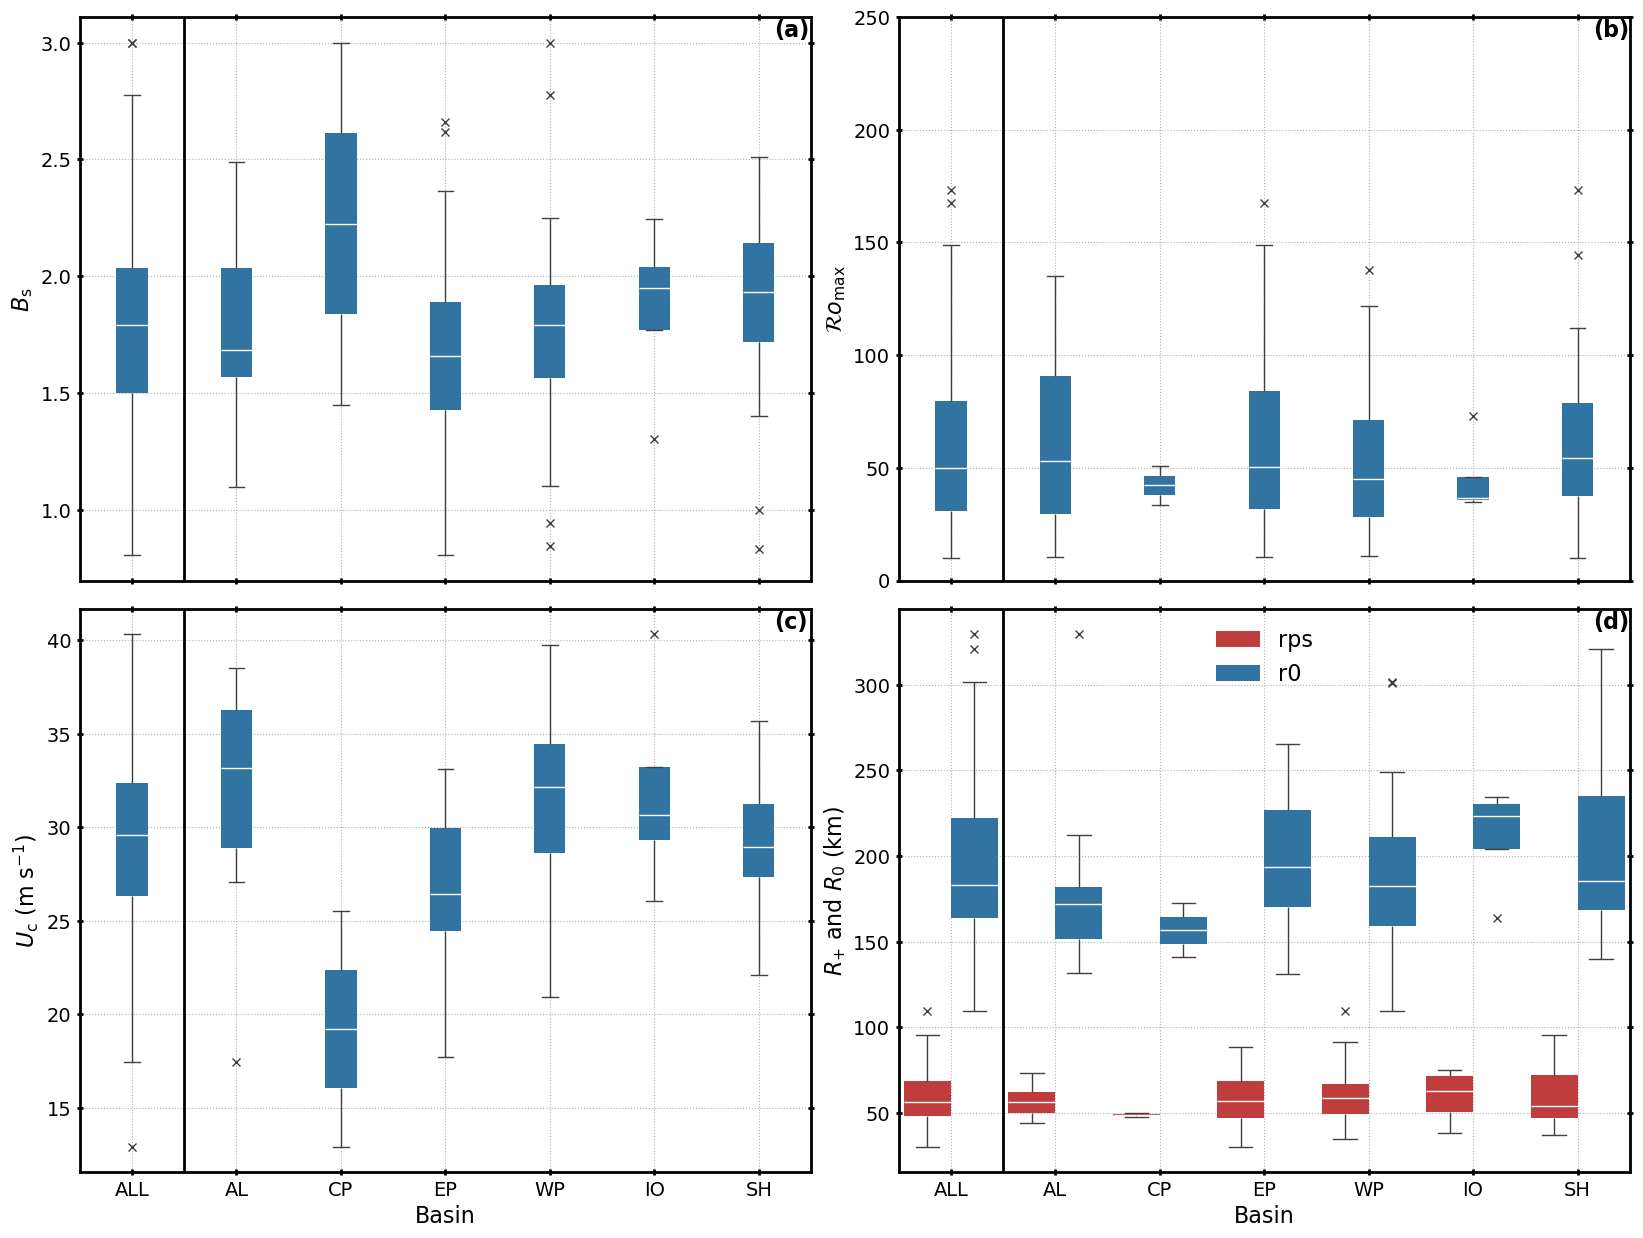

In [13]:
# Hyperparameters
width      = 0.3
bins       = np.arange(0 - width * 1.108 / 2, 6 + width * 1.108 / 2, width * 1.108)
color_glob = 'tab:blue'
color_r50  = 'tab:red'
color_r64  = 'tab:green'

# Fig.
fig        = plt.figure(figsize=(20, 15))
gs         = GridSpec(2, 2, hspace=0.05, wspace=0.12, height_ratios=[2, 2])

############
###  Bs  ###
############
ax = fig.add_subplot(gs[0, 0])
ax.text(0.95, 0.965, '(a)', transform=ax.transAxes, weight='bold')

# Data pre.
df                     = d[['basin_idx', 'B_hol']].to_dataframe()
df_plot                = df.melt(id_vars='basin_idx', value_vars=['B_hol'])
df_global              = df_plot.copy()
df_global['basin_idx'] = 0
df_combined            = pd.concat([df_plot, df_global])
# Colors
palette                = {'B_hol': color_glob}

# Boxplot
g = sns.boxplot(
    x='basin_idx', 
    y='value', 
    hue='variable', 
    data=df_combined, 
    boxprops={'edgecolor':'none'},
    palette=palette,
    medianprops={'color': 'white'},
    flierprops=dict(marker='x', color='grey'),
    width=width,
)

# Separation for All vs. basins
ax.axvline(0.5, c='k', linewidth=2)

# Labels
# xlabels = [basin_keys_combined[round(float(l.get_text()))].upper() for l in g.get_xticklabels()]
# g.set_xticklabels(xlabels)
# g.set_xlabel('Basin')
ax.set_xticklabels([])
ax.set_xlabel('')
g.set_ylabel(r'$B_{\text{s}}$')
# ax.legend(frameon=False, loc='upper center')
ax.legend_.remove()
# Put the y ticks label ont the right 
# The same can be done to put the xlabel at the top
ax.yaxis.set_label_position("left") 
plt.xticks(fontsize=fontsize - 2) #the x-ticks 
plt.yticks(fontsize=fontsize - 2) #the y-ticks 

# Grids
# Frame for the plot (do this after the right label position otherwise missing ticks)
ax.spines['left'].set_linewidth(2) #set the width of axis lines -> version without loop
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)       
ax.tick_params(direction='inout', width=2, length=5, bottom=1, top=1, left=1, right=1) #set the tick parameters
ax.grid(ls=':')
ax.set_axisbelow(True) # Set the grid in background

############
### Rsby ###
############
ax = fig.add_subplot(gs[0, 1])
ax.text(0.95, 0.965, '(b)', transform=ax.transAxes, weight='bold')

# Data pre.
df                     = d[['basin_idx', 'rsby']].to_dataframe()
df_plot                = df.melt(id_vars='basin_idx', value_vars=['rsby'])
df_global              = df_plot.copy()
df_global['basin_idx'] = 0
df_combined            = pd.concat([df_plot, df_global])
# Colors
palette                = {'rsby': color_glob}

# Boxplot
g = sns.boxplot(
    x='basin_idx', 
    y='value', 
    hue='variable', 
    data=df_combined, 
    boxprops={'edgecolor':'none'},
    palette=palette,
    medianprops={'color': 'white'},
    flierprops=dict(marker='x', color='grey'),
    width=width,
)

# Separation for All vs. basins
ax.axvline(0.5, c='k', linewidth=2)

# Labels
# xlabels = [basin_keys_combined[round(float(l.get_text()))].upper() for l in g.get_xticklabels()]
# g.set_xticklabels(xlabels)
# g.set_xlabel('Basin')
ax.set_xticklabels([])
ax.set_xlabel('')
g.set_ylabel(r'$\mathcal{R}o_{\text{max}}$')
# ax.legend(frameon=False, loc='upper center')
ax.legend_.remove()
# Put the y ticks label ont the right 
# The same can be done to put the xlabel at the top
ax.yaxis.set_label_position("left") 
plt.xticks(fontsize=fontsize - 2) #the x-ticks 
plt.yticks(fontsize=fontsize - 2) #the y-ticks 

# Grids
# Frame for the plot (do this after the right label position otherwise missing ticks)
ax.spines['left'].set_linewidth(2) #set the width of axis lines -> version without loop
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)       
ax.tick_params(direction='inout', width=2, length=5, bottom=1, top=1, left=1, right=1) #set the tick parameters
ax.grid(ls=':')
ax.set_axisbelow(True) # Set the grid in background

ax.set_ylim(0, 250)

############
###  Uc  ###
############
ax = fig.add_subplot(gs[1, 0])
ax.text(0.95, 0.965, '(c)', transform=ax.transAxes, weight='bold')

# Data pre.
df                     = d[['basin_idx', 'uc']].to_dataframe()
df_plot                = df.melt(id_vars='basin_idx', value_vars=['uc'])
df_plot['value']       = abs(df_plot['value'])
df_global              = df_plot.copy()
df_global['basin_idx'] = 0
df_combined            = pd.concat([df_plot, df_global])
# Colors
palette                = {'uc': color_glob}

# Boxplot
g = sns.boxplot(
    x='basin_idx', 
    y='value', 
    hue='variable', 
    data=df_combined, 
    boxprops={'edgecolor':'none'},
    palette=palette,
    medianprops={'color': 'white'},
    flierprops=dict(marker='x', color='grey'),
    width=width,
)

# Separation for All vs. basins
ax.axvline(0.5, c='k', linewidth=2)

# Labels
xlabels = [basin_keys_combined[round(float(l.get_text()))].upper() for l in g.get_xticklabels()]
g.set_xticklabels(xlabels)
g.set_xlabel('Basin')
g.set_ylabel(r'$U_{\text{c}}$ (m s$^{-1}$)')
# ax.legend(frameon=False, loc='upper center')
ax.legend_.remove()
# Put the y ticks label ont the right 
# The same can be done to put the xlabel at the top
ax.yaxis.set_label_position("left") 
plt.xticks(fontsize=fontsize - 2) #the x-ticks 
plt.yticks(fontsize=fontsize - 2) #the y-ticks 

# Grids
# Frame for the plot (do this after the right label position otherwise missing ticks)
ax.spines['left'].set_linewidth(2) #set the width of axis lines -> version without loop
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)       
ax.tick_params(direction='inout', width=2, length=5, bottom=1, top=1, left=1, right=1) #set the tick parameters
ax.grid(ls=':')
ax.set_axisbelow(True) # Set the grid in background

############
### Rxx  ###
############
ax = fig.add_subplot(gs[1, 1])
ax.text(0.95, 0.965, '(d)', transform=ax.transAxes, weight='bold')

# Data pre.
df                     = d[['basin_idx', 'rps', 'r0']].to_dataframe()
df_plot                = df.melt(id_vars='basin_idx', value_vars=['rps', 'r0'])
df_plot['value']       = df_plot['value'] / 1000
df_global              = df_plot.copy()
df_global['basin_idx'] = 0
df_combined            = pd.concat([df_plot, df_global])
# # Code updated because it did no longer work
df_combined            = df_combined.reset_index()
# Colors
palette = {
    'r0':  color_glob, 
    'rps': 'tab:red'
}

# Boxplot
g = sns.boxplot(
    x='basin_idx', 
    y='value', 
    hue='variable', 
    data=df_combined, 
    boxprops={'edgecolor':'none'},
    palette=palette,
    medianprops={'color': 'white'},
    flierprops=dict(marker='x', color='grey'),
    width=width * 3,
)

# Separation for All vs. basins
ax.axvline(0.5, c='k', linewidth=2)

# Labels
xlabels = [basin_keys_combined[round(float(l.get_text()))].upper() for l in g.get_xticklabels()]
g.set_xticklabels(xlabels)
g.set_xlabel('Basin')
g.set_ylabel(r'$R_{\text{+}}$ and $R_{\text{0}}$ (km)')
ax.legend(frameon=False, loc='upper center')
# ax.legend_.remove()
# Put the y ticks label ont the right 
# The same can be done to put the xlabel at the top
ax.yaxis.set_label_position("left") 
plt.xticks(fontsize=fontsize - 2) #the x-ticks 
plt.yticks(fontsize=fontsize - 2) #the y-ticks 

# Grids
# Frame for the plot (do this after the right label position otherwise missing ticks)
ax.spines['left'].set_linewidth(2) #set the width of axis lines -> version without loop
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)       
ax.tick_params(direction='inout', width=2, length=5, bottom=1, top=1, left=1, right=1) #set the tick parameters
ax.grid(ls=':')
ax.set_axisbelow(True) # Set the grid in background

# plt.savefig(PTHS['sav_dir'] + 'dynamical_prms_by_basin.png', bbox_inches='tight')

In [14]:
print('Vmax = {:.1f} m/s'.format(d.vmx.median()))
print('Rmax = {:.1f} km'.format(d.rmx.median() / 1000))
print('|f|  = {:.1f}e-5 s-1'.format(abs(d.fcor.median()) * 1e5))
print('R34 = {:.1f} km'.format(d.r34.median() / 1000))
print('R50 = {:.1f} km'.format(d.r50.median() / 1000))
print('R64 = {:.1f} km'.format(d.r64.median() / 1000))
print('')
print('B_hol = {:.1f}'.format(d.B_hol.median()))
print('Romax = {:.1f}'.format(d.rsby.median()))
print('Uc = {:.1f} m/s'.format(d.uc.median()))
print('R0 = {:.1f} km'.format(d.r0.median() / 1000))
print('R+ = {:.1f} km'.format(d.rps.median() / 1000))

Vmax = 45.2 m/s
Rmax = 19.0 km
|f|  = 4.3e-5 s-1
R34 = 133.5 km
R50 = 71.5 km
R64 = 48.0 km

B_hol = 1.8
Romax = 50.1
Uc = 29.6 m/s
R0 = 182.8 km
R+ = 56.3 km


In [15]:
print('Vmax IBTrACS = {:.1f} m/s'.format(dsi_stacked.vmx_reg.median()))

Vmax IBTrACS = 28.8 m/s
